In [8]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML
import re

def summarize_by_config(results_dir='../results/create_weights'):
    results_path = Path(results_dir)
    csv_files = list(results_path.glob("*.csv"))
    
    if not csv_files:
        print(f"在 {results_dir} 下未找到任何 CSV 文件。")
        return

    # 1. 按照 (wsize, stride) 对文件进行分组
    configs = {}
    for f in csv_files:
        name = f.stem
        match = re.search(r'wsize_?(\d+)_stride_?(\d+)', name)
        if match:
            config_key = f"wsize {match.group(1)} | stride {match.group(2)}"
        else:
            config_key = "Default/Other Config"
            
        if config_key not in configs:
            configs[config_key] = []
        configs[config_key].append(f)

    # 2. 遍历每个配置，生成汇总表
    for config_name, files in configs.items():
        overall_rows = []
        
        for f in files:
            df = pd.read_csv(f)
            metric_cols = [c for c in df.columns if c not in ['battery', 'window_start']]
            
            # 提取文件名末尾标识
            file_suffix = f.stem.split('_')[-1]
            
            if file_suffix == 'train':
                # --- 特殊处理 Train 文件 ---
                # A. 细分统计：按 battery 前缀分组 (如 HUST, MATR)
                df['ds_prefix'] = df['battery'].apply(lambda x: f"Train_{x.split('_')[0]}")
                sub_means = df.groupby('ds_prefix')[metric_cols].mean()
                sub_counts = df.groupby('ds_prefix')['battery'].count()
                
                for ds_prefix in sub_means.index:
                    row = sub_means.loc[[ds_prefix]].copy()
                    row.insert(0, 'sample_count', sub_counts[ds_prefix])
                    overall_rows.append(row)
                
                # B. 整体统计：Train_Set(Total)
                total_mean = df[metric_cols].mean().to_frame().T
                total_mean.index = ["Train_Set(Total)"]
                total_mean.insert(0, 'sample_count', len(df))
                overall_rows.append(total_mean)
                
            else:
                # --- 处理常规测试文件 (NAion, ZNion 等) ---
                mean_vals = df[metric_cols].mean().to_frame().T
                mean_vals.index = [file_suffix]
                mean_vals.insert(0, 'sample_count', len(df))
                overall_rows.append(mean_vals)
        
        # 合并当前配置下的所有结果
        if overall_rows:
            summary_df = pd.concat(overall_rows).sort_index()
            
            # 3. 输出
            display(HTML(f"<h3>配置汇总: {config_name}</h3>"))
            # 仅设置精度，不做颜色装饰
            display(summary_df.style.format(precision=6))
            print("\n")

# 调用函数
summarize_by_config()

,sample_count,mse_win,mae_win,rmse_win,mse_bat,mae_bat,rmse_bat
CALCE,160,0.000088,0.007157,0.008930,0.002756,0.036328,0.048913
HNEI,97,0.000025,0.003464,0.004748,0.000348,0.010604,0.016872
HUST,535,0.000060,0.005769,0.006738,0.005397,0.050589,0.064293
MATR,384,0.000121,0.007722,0.009242,0.004040,0.037543,0.061142
NAion,38,0.000024,0.002691,0.003504,0.000030,0.003039,0.004049
Train_HUST,1966,0.000056,0.005673,0.006652,0.005682,0.053396,0.067467
Train_ISU-ILCC,55,0.000108,0.006523,0.008685,0.000648,0.016049,0.023629
Train_MATR,1555,0.000116,0.008052,0.009260,0.002203,0.031160,0.044345
Train_MICH,211,0.001100,0.013561,0.014013,0.001223,0.017274,0.021057
Train_RWTH,822,0.000098,0.007208,0.009489,0.003370,0.041114,0.055704


根据soh返回进行权重可视化

BatteryData 模块导入成功！
Step 1: 扫描原始数据索引...
Step 2: 提取权重、SOH与元数据...


处理中:   0%|          | 33/8117 [00:01<05:32, 24.35it/s]

处理中: 100%|██████████| 8117/8117 [02:12<00:00, 61.27it/s]  



生成全局总图...


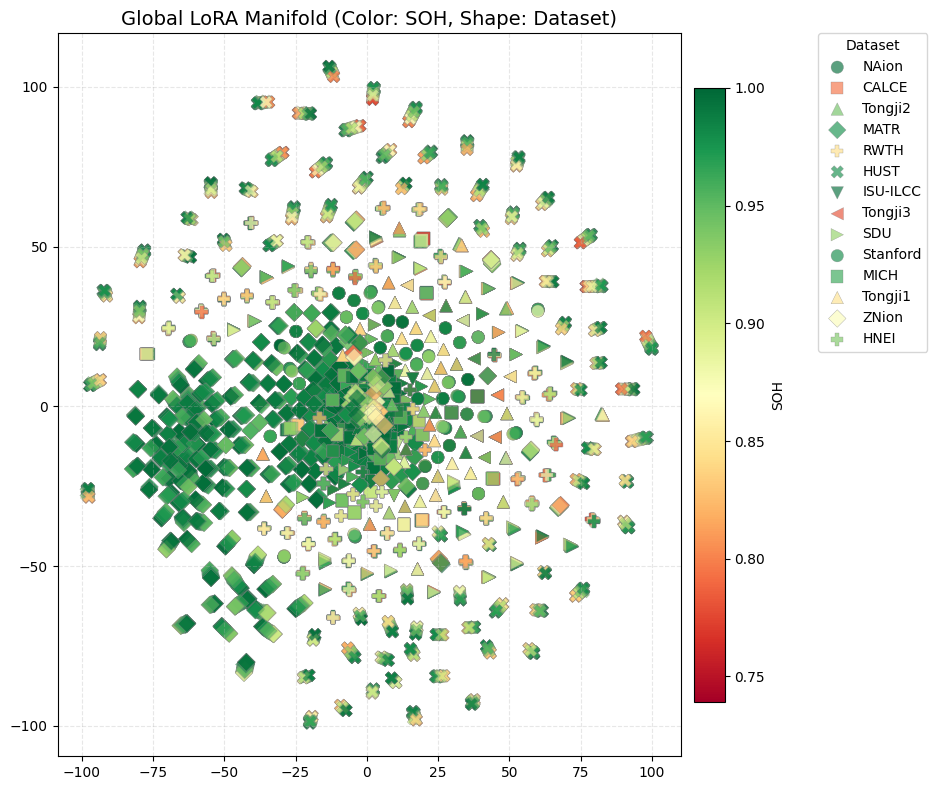


完成！所有图片保存在: lora_vis_final


In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from tqdm import tqdm
import gc
import sys

# 基础设置
os.environ['OMP_NUM_THREADS'] = '1'
%matplotlib inline

# 导入 BatteryData 路径处理
code_root = str(Path("../").resolve()) 
if code_root not in sys.path:
    sys.path.append(code_root)

try:
    from battery_data import BatteryData
    print("BatteryData 模块导入成功！")
except ImportError:
    print("找不到 battery_data.py")

def plot_enhanced_tsne(df, title, output_path, hue_col='SOH_Start', style_col='Dataset'):
    """
    高度整合的绘图函数：颜色代表SOH，形状代表数据集
    """
    if len(df) < 5:
        return
    
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    
    # 准备 t-SNE 数据
    weights_data = np.stack(df['weight_vec'].values)
    perp = min(30, len(df) - 1)
    tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=perp)
    embedding = tsne.fit_transform(weights_data)
    
    df_plot = df.copy()
    df_plot['x'] = embedding[:, 0]
    df_plot['y'] = embedding[:, 1]
    
    # 颜色仅映射 SOH 数值，并用 colorbar 表示
    norm = plt.Normalize(df_plot[hue_col].min(), df_plot[hue_col].max())
    cmap = plt.cm.RdYlGn
    
    # 形状用于区分数据集，图例只保留数据集信息
    marker_list = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
    datasets = list(df_plot[style_col].dropna().unique())
    for i, ds in enumerate(datasets):
        part = df_plot[df_plot[style_col] == ds]
        ax.scatter(
            part['x'], part['y'],
            c=part[hue_col], cmap=cmap, norm=norm,
            marker=marker_list[i % len(marker_list)],
            s=80, alpha=0.65, edgecolors='gray', linewidths=0.3,
            label=ds
        )
    
    # 设置颜色条
    sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label('SOH', fontsize=10)
    
    plt.title(title, fontsize=14)
    plt.legend(bbox_to_anchor=(1.22, 1), loc='upper left', borderaxespad=0, title=style_col)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

def visualize_combined_lora(weights_root, labeled_data_root, save_dir="vis_combined", window_size=200):
    weights_root = Path(weights_root)
    labeled_data_root = Path(labeled_data_root)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    soh_cache = {} 
    all_data = []

    print("Step 1: 扫描原始数据索引...")
    origin_map = {f.stem: f for f in labeled_data_root.rglob("*.pkl")}
    weight_files = list(weights_root.rglob("*.pkl"))

    print("Step 2: 提取权重、SOH与元数据...")
    for f in tqdm(weight_files, desc="处理中"):
        try:
            # 1. 解析文件名与分组
            # 结构假设：weights_root / Group / Dataset_Cell_Idx.pkl
            group_name = f.parent.name
            name_parts = f.stem.rsplit('_', 1)
            cell_id = name_parts[0]  
            start_idx = int(name_parts[1]) 
            dataset_name = f.stem.split('_')[0] # 提取数据集标识

            # 2. 读取 SOH
            if cell_id not in soh_cache:
                target_file = origin_map.get(cell_id)
                if not target_file and "_" in cell_id: # 模糊匹配
                    short_id = cell_id.split("_", 1)[1]
                    target_file = origin_map.get(short_id)
                
                if target_file:
                    bat = BatteryData.load(str(target_file))
                    soh_cache[cell_id] = [c.labeled_soh for c in bat.cycle_data]
                    del bat
                else: continue
            
            soh_list = soh_cache[cell_id]
            if start_idx >= len(soh_list): continue
            
            # 3. 加载权重
            weights = torch.load(f, map_location='cpu')
            W = torch.matmul(weights['param_A'], weights['param_B']).numpy().flatten()
            
            all_data.append({
                'weight_vec': W,
                'Group': group_name,
                'Dataset': dataset_name,
                'SOH_Start': soh_list[start_idx],
                'Cell_ID': cell_id
            })
            
            if len(all_data) % 1000 == 0: gc.collect()
        except Exception: continue

    df = pd.DataFrame(all_data)
    if df.empty: return print("❌ 无有效数据")

    # --- 任务 1: 全局大图 (颜色=SOH, 形状=Dataset) ---
    print("\n生成全局总图...")
    plot_enhanced_tsne(df, "Global LoRA Manifold (Color: SOH, Shape: Dataset)", 
                       save_dir / "00_global_soh_dataset.png")

    # # --- 任务 2: 按 Group 生成子图 ---
    # print("生成分组独立图...")
    # for group_name, g_df in df.groupby('Group'):
    #     print(f"  Processing Group: {group_name}")
    #     plot_enhanced_tsne(g_df, f"Group: {group_name} (Color: SOH, Shape: Dataset)", 
    #                        save_dir / f"group_{group_name}_soh.png")

    # # --- 任务 3: 按 Dataset 生成子图 ---
    # print("生成数据集独立图...")
    # for ds_name, d_df in df.groupby('Dataset'):
    #     # 在单一数据集图中，形状可以用 Cell_ID 区分或保持统一
    #     print(f"  Processing Dataset: {ds_name}")
    #     plot_enhanced_tsne(d_df, f"Dataset: {ds_name} (Color: SOH, Shape: Cell)", 
    #                        save_dir / f"dataset_{ds_name}_soh.png", style_col='Cell_ID')

    print(f"\n完成！所有图片保存在: {save_dir}")

# 执行命令
visualize_combined_lora(
    weights_root="../data/weights/wsize_200_stride_50", 
    labeled_data_root="../data/labeled",
    save_dir="lora_vis_final"
)

In [14]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def analyze_trajectory_consistency(weights_root):
    """
    计算不同电池 LoRA 权重演化轨迹的方向一致性
    """
    weights_root = Path(weights_root)
    trajectories = {}

    print("Step 1: 提取各电池演化轨迹...")
    # 遍历所有权重文件
    weight_files = list(weights_root.rglob("*.pkl"))
    for f in tqdm(weight_files):
        try:
            # 文件名解析: NASA_B0005_0.pkl
            name_parts = f.stem.rsplit('_', 1)
            cell_id = name_parts[0]
            start_idx = int(name_parts[1])
            
            data = torch.load(f, map_location='cpu')
            # 计算 W = A @ B
            W = torch.matmul(data['param_A'], data['param_B']).numpy().flatten()
            
            if cell_id not in trajectories:
                trajectories[cell_id] = []
            trajectories[cell_id].append((start_idx, W))
        except: continue

    # Step 2: 计算每个电池的总位移向量 (Final_W - Initial_W)
    cell_vectors = []
    cell_names = []
    
    print("\nStep 2: 计算位移向量...")
    for cell_id, data_list in trajectories.items():
        if len(data_list) < 2: continue
        
        # 按时间步排序
        data_list.sort(key=lambda x: x[0])
        initial_w = data_list[0][1]
        final_w = data_list[-1][1]
        
        # 计算该电池在参数空间的总移动方向
        move_vector = final_w - initial_w
        cell_vectors.append(move_vector)
        cell_names.append(cell_id)

    if not cell_vectors:
        return print("数据不足，无法分析。")

    # Step 3: 计算余弦相似度矩阵
    vectors_matrix = np.stack(cell_vectors)
    sim_matrix = cosine_similarity(vectors_matrix)

    # Step 4: 结果分析
    avg_sim = (np.sum(sim_matrix) - len(cell_names)) / (len(cell_names) * (len(cell_names) - 1))
    
    print("\n" + "="*30)
    print(f"轨迹一致性分析报告")
    print("-" * 30)
    print(f"分析电池总数: {len(cell_names)}")
    print(f"全局平均余弦相似度: {avg_sim:.4f}")
    print("注: 1.0 表示完全平行，0.0 表示垂直，负数表示方向相反。")
    print("="*30)

    # 找出最不一致的例子进行对比
    min_idx = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape)
    print(f"方向差异最大的两颗电池: {cell_names[min_idx[0]]} vs {cell_names[min_idx[1]]}")
    print(f"它们的轨迹夹角相似度仅为: {sim_matrix[min_idx]:.4f}")

# 执行分析
analyze_trajectory_consistency("../data/weights/wsize_200_stride_50")

Step 1: 提取各电池演化轨迹...


  0%|          | 0/8117 [00:00<?, ?it/s]

100%|██████████| 8117/8117 [00:02<00:00, 3137.59it/s]


Step 2: 计算位移向量...

轨迹一致性分析报告
------------------------------
分析电池总数: 594
全局平均余弦相似度: 0.0295
注: 1.0 表示完全平行，0.0 表示垂直，负数表示方向相反。
方向差异最大的两颗电池: HUST_7-8 vs MICH_MCForm26_pouch_NMC_25C_0-100_1-1C_f
它们的轨迹夹角相似度仅为: -0.3846


In [15]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def analyze_intra_dataset_consistency(weights_root):
    """
    计算相同数据集内部电池 LoRA 权重演化轨迹的方向一致性
    """
    weights_root = Path(weights_root)
    trajectories = {}

    print("Step 1: 提取各电池演化轨迹...")
    weight_files = list(weights_root.rglob("*.pkl"))
    for f in tqdm(weight_files):
        try:
            # 文件名解析，假设格式为: Dataset_CellID_StartIdx.pkl
            name_parts = f.stem.rsplit('_', 1)
            cell_id = name_parts[0]
            start_idx = int(name_parts[1])
            
            data = torch.load(f, map_location='cpu')
            # 计算 W = A @ B
            W = torch.matmul(data['param_A'], data['param_B']).numpy().flatten()
            
            if cell_id not in trajectories:
                trajectories[cell_id] = []
            trajectories[cell_id].append((start_idx, W))
        except: continue

    # Step 2: 按数据集分组计算位移向量
    dataset_groups = {}
    
    print("\nStep 2: 计算各体系位移向量...")
    for cell_id, data_list in trajectories.items():
        if len(data_list) < 2: continue
        
        # 提取数据集名称 (假设 ID 的第一个前缀是数据集名，如 HUST_10-6 -> HUST)
        dataset_name = cell_id.split('_')[0]
        
        # 按时间步排序并计算总位移向量 (Final_W - Initial_W)
        data_list.sort(key=lambda x: x[0])
        move_vector = data_list[-1][1] - data_list[0][1]
        
        if dataset_name not in dataset_groups:
            dataset_groups[dataset_name] = {'vectors': [], 'names': []}
        dataset_groups[dataset_name]['vectors'].append(move_vector)
        dataset_groups[dataset_name]['names'].append(cell_id)

    # Step 3 & 4: 结果分析与报表输出
    print("\n" + "="*60)
    print(f"{'数据集 (Dataset)':<15} | {'样本数':<6} | {'类内平均相似度':<10}")
    print("-" * 60)

    all_intra_sims = []
    for ds_name, group in dataset_groups.items():
        vectors = group['vectors']
        n = len(vectors)
        
        if n < 2:
            print(f"{ds_name:<15} | {n:<8} | {'数据不足':<10}")
            continue

        # 计算该数据集内部的余弦相似度矩阵
        vectors_matrix = np.stack(vectors)
        sim_matrix = cosine_similarity(vectors_matrix)
        
        # 计算排除对角线后的平均相似度
        intra_sim = (np.sum(sim_matrix) - n) / (n * (n - 1))
        all_intra_sims.append(intra_sim)
        
        print(f"{ds_name:<15} | {n:<8} | {intra_sim:.4f}")

    print("-" * 60)
    if all_intra_sims:
        print(f"所有数据集的平均类内相似度: {np.mean(all_intra_sims):.4f}")
    print("="*60)

# 执行类内一致性分析
analyze_intra_dataset_consistency("../data/weights/wsize_200_stride_50")

Step 1: 提取各电池演化轨迹...


  0%|          | 0/8117 [00:00<?, ?it/s]

100%|██████████| 8117/8117 [00:04<00:00, 1988.98it/s]


Step 2: 计算各体系位移向量...

数据集 (Dataset)   | 样本数    | 类内平均相似度   
------------------------------------------------------------
CALCE           | 13       | 0.0682
Tongji2         | 35       | 0.0329
MATR            | 166      | 0.0932
RWTH            | 48       | 0.1632
HUST            | 77       | 0.1041
ISU-ILCC        | 13       | 0.0503
Tongji3         | 9        | 0.0923
SDU             | 57       | 0.0634
Stanford        | 41       | 0.0494
MICH            | 49       | 0.0216
Tongji1         | 30       | 0.0395
ZNion           | 42       | 0.0200
HNEI            | 14       | 0.0356
------------------------------------------------------------
所有数据集的平均类内相似度: 0.0641
